In [32]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("./datasets/_data.csv")
df.head(2)

,Unnamed: 0,ID объявления,Количество комнат,Тип,Метро,Адрес,"Площадь, м2",Дом,Парковка,Цена,...,Окна,Санузел,Можно с детьми/животными,Дополнительно,Название ЖК,Серия дома,"Высота потолков, м",Лифт,Мусоропровод,Ссылка на объявление
0,0,271271157,4,Квартира,м. Смоленская (9 мин пешком),"Москва, улица Новый Арбат, 27",200.0/20.0,"5/16, Монолитный",подземная,"500000.0 руб./ За месяц, Залог - 500000 руб., ...",...,NaN,NaN,"Можно с детьми, Можно с животными","Мебель в комнатах, Мебель на кухне, Ванна, Душ...","Новый Арбат, 2010",NaN,3.0,"Пасс (4), Груз (1)",Да,https://www.cian.ru/rent/flat/271271157
1,1,271634126,4,Квартира,м. Смоленская (8 мин пешком),"Москва, улица Новый Арбат, 27",198.0/95.0/18.0,"5/16, Монолитно-кирпичный",подземная,"500000.0 руб./ За месяц, Залог - 500000 руб., ...",...,На улицу и двор,"Совмещенный (2), Раздельный (1)",Можно с детьми,"Мебель в комнатах, Мебель на кухне, Ванна, Душ...",Новый Арбат,NaN,3.5,"Пасс (1), Груз (1)",Нет,https://www.cian.ru/rent/flat/271634126


In [ ]:
column = 'Площадь комнат, м2'
num_null = df[column].isnull().sum()
print(df[column].unique())
print((df.shape[0] - num_null) / df.shape[0])

<StringArray>
[                       nan,              '25 25 20 25',
              '14-42-20-19',                    '20 18',
           '43-25-25-25-22',                 '26 22 15',
                 '45 25 25',              '16 14 16 20',
              '16-40-20-18',                       '80',
 ...
                  '17,3+14',                    '28-22',
                 '14+14+19',              '19-19-19+20',
 '26.6-22.1-25.5-17.6-18.9',                  '18+10.5',
                 '10-17+12',                 '22-16-30',
             '32+13,6-18,7',           '26,2+15,5-22,0']
Length: 3991, dtype: str
0.6187093461143444


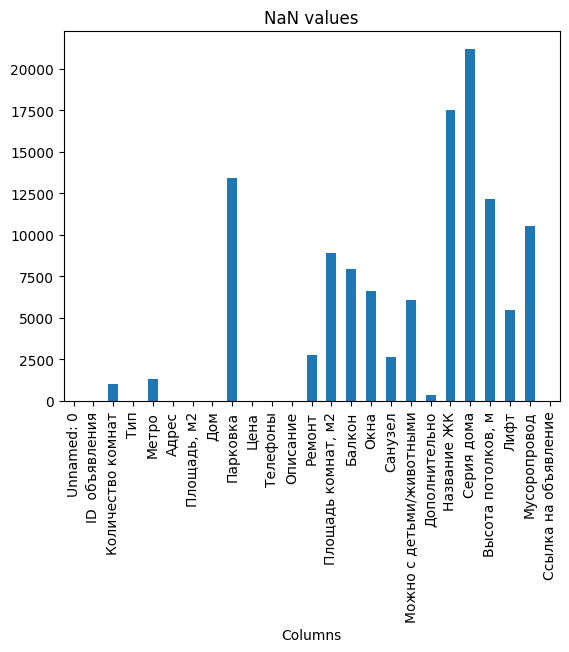

In [33]:
nan = df.isna().sum()
nan.plot(kind='bar')
plt.title("NaN values")
plt.xlabel('Columns')
plt.show()

In [28]:
df['Балкон'].unique()

<StringArray>
[                     nan,             'Балкон (1)',             'Балкон (3)',
             'Лоджия (1)', 'Балкон (2), Лоджия (3)', 'Балкон (1), Лоджия (1)',
             'Балкон (2)',             'Лоджия (2)', 'Балкон (3), Лоджия (3)',
 'Балкон (3), Лоджия (1)',             'Лоджия (3)', 'Балкон (1), Лоджия (2)',
 'Балкон (2), Лоджия (1)', 'Балкон (2), Лоджия (2)', 'Балкон (1), Лоджия (3)',
             'Балкон (4)',             'Лоджия (4)', 'Балкон (4), Лоджия (4)',
 'Балкон (1), Лоджия (4)']
Length: 19, dtype: str

In [29]:
df['Окна'].unique()

<StringArray>
[nan, 'На улицу и двор', 'Во двор', 'На улицу']
Length: 4, dtype: str

In [ ]:
columns = df.columns
columns

# добавлям 0, где нет значей
add_zero_columns = ['Парковка', 'Лифт', 'Ремонт', 'Балкон'] # фиксированное кол-во значений

drop_columns = ['Тип','Телефоны', 'Описание', 'Площадь комнат, м2', 'Окна', 'Санузел',
       'Можно с детьми/животными', 'Дополнительно', 'Название ЖК', 'Серия дома',
       'Высота потолков, м','Мусоропровод',
       'Ссылка на объявление']

#разделить -> в цифру
'Количество комнат' 
'Дом'
'Метро', -> lat/lon
'Адрес', -> город 
'Площадь, м2',
'Цена'

# убрать строки, где не москва


Index(['Unnamed: 0', 'ID  объявления', 'Количество комнат', 'Тип', 'Метро',
       'Адрес', 'Площадь, м2', 'Дом', 'Парковка', 'Цена', 'Телефоны',
       'Описание', 'Ремонт', 'Площадь комнат, м2', 'Балкон', 'Окна', 'Санузел',
       'Можно с детьми/животными', 'Дополнительно', 'Название ЖК',
       'Серия дома', 'Высота потолков, м', 'Лифт', 'Мусоропровод',
       'Ссылка на объявление'],
      dtype='str')